In [1]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd

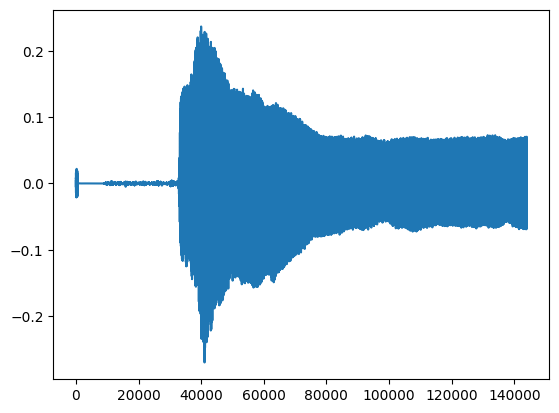

In [132]:
# fs = 44100  # Sample rate given in sounddevice example 
fs = 48e3
seconds = 3 # Duration of recording

myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()  # Wait until recording is finished
plt.plot(myrecording)

This vocoder implements an  LCCDE representing transfer function

https://www.quantum-machines.co/blog/introduction-to-digital-filters-01-first-things-first/

$$ \begin{equation}
    H(z)  = \frac{\sum_{k=0}^N b_k z^{-k}}{\sum_{k=1}^M a_k z^{-k}}
    \end{equation}
$$


Human voice frequencies: human vocal range 

Total bandwidth: 50Hz-7kHz. Split equally in three to start. 
Procedure is to filter the microphone input (voice) and filter the sawtooth (pitch) with B1. Then mix the results. Repeat the same for B2 and B3. Add all the mixed signals together to produce the output
The sawtooth is produced by 

In [163]:
# Choose bandwidth ranges 
fmin = 50
fmax = 7e3
segment = (fmax-fmin)/3 # divide bandwidth equally into three segments 
band1 = fmin + segment
band2 = band1 + segment
band3 = band2 + segment

# Choose filter order 
Norder = 4

# Extract FIR bandpass filter coefficients for each bandwidth
iir_b1, iir_a1 = np.array(sig.iirfilter(N = Norder, Wn=[fmin, band1], btype='bandpass', output='ba', fs=fs)) # cutoff should correspond with -6dB 
iir_b2, iir_a2 = np.array(sig.iirfilter(N = Norder, Wn=[band1, band2], btype='bandpass', output='ba', fs=fs)) 
iir_b3, iir_a3 = np.array(sig.iirfilter(N = Norder, Wn=[band2, band3], btype='bandpass',  output='ba', fs=fs)) 

# Create a test sinusoid 
f0 = 60
A = 5
phi = 0
n = np.arange(0, 1000)
x = A*np.cos(2*np.pi*(f0/fs)*n+phi)

# Filter the recordign
x = myrecording

# Calculate filtering action using lfilter function 
mic_iir_1 = sig.lfilter(iir_b1, iir_a1, x=x)
mic_iir_2 = sig.lfilter(iir_b2, iir_a2, x=x)
mic_iir_3 = sig.lfilter(iir_b3, iir_a3, x=x)


# Generate sawtooth 
periods = 60
samples = len(x)
n = np.linspace(0, periods*2*np.pi, samples)
pitch = sig.sawtooth(n, 0.2)

# Calculate filtering action using lfilter function 
pitch_iir_1 = sig.lfilter(iir_b1, iir_a1, x=pitch)
pitch_iir_2 = sig.lfilter(iir_b2, iir_a2, x=pitch)
pitch_iir_3 = sig.lfilter(iir_b3, iir_a3, x=pitch)

out = [1e5*(mic_iir_1[i]*pitch_iir_1[i] + mic_iir_2[i]*pitch_iir_2[i] + mic_iir_3[i]*pitch_iir_3[i]) for i in range(len(mic_iir_1))]


In [157]:
sd.play(myrecording, fs)

In [164]:
sd.play(out, fs)